1) Identify the prediction target

The dataset objective is to predict whether a client subscribes to a term deposit. 
In this dataset, the target is typically y (yes/no).

Two variables that might look like targets but should not be used as objectives:

1) duration (call duration): it’s highly predictive but is not truly “available at the time of contact decision” in many real settings; it can act like leakage / post-outcome info. (This is also a good “special consideration” feature to discuss.) --> TEMPORAL LEAKAGE

2) campaign: the assignment is explicit that we only use information available at prediction time

2) Data loading and first inspection (EDA)

What we do: load CSV, inspect shape/dtypes/summary stats, identify numerical vs categorical variables, check target distribution (imbalance), detect explicit + implicit missing values (“unknown”), and visualize a couple of variables

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("bank-additional.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [6]:
print("Shape:", df.shape)
df.info()

Shape: (4119, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx  

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4119.0,NaN,NaN,NaN,40.11362,10.313362,18.0,32.0,38.0,47.0,88.0
job,4119,12,admin.,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4119,4,married,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4119,8,university.degree,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4119,3,no,3315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,4119,3,yes,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4119,3,no,3349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4119,2,cellular,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,4119,10,may,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,4119,5,thu,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Define prediction target

In [9]:
assert "y" in df.columns, "Expected target column 'y' in the dataset."
X = df.drop(columns=["y"]).copy()
y = df["y"].map({"no": 0, "yes": 1})  # logistic regression needs numeric target

y.value_counts(), y.mean()

(y
 0    3668
 1     451
 Name: count, dtype: int64,
 0.10949259529011895)

Identify numerical and categorical var

In [11]:
numerical_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical variables:", numerical_vars)
print("Categorical variables:", categorical_vars)


Numerical variables: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [12]:
df["y"].value_counts()


y
no     3668
yes     451
Name: count, dtype: int64

In [13]:
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

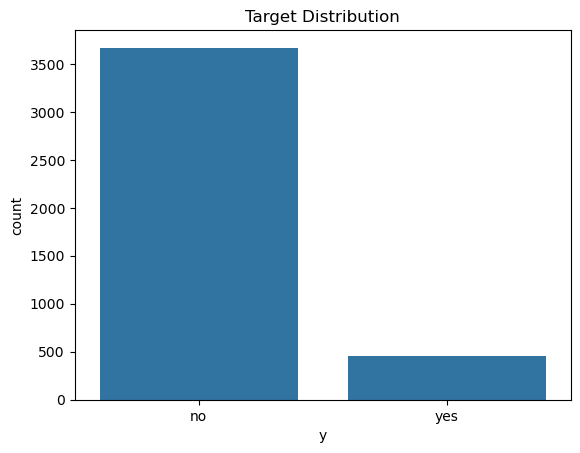

In [14]:
sns.countplot(x="y", data=df)
plt.title("Target Distribution")
plt.show()


There is class imbalance, especially skewed towards no. This may affect the model's performance and recall score.


Detect explicit values

In [17]:
df.isna().sum().sort_values(ascending=False)

age               0
campaign          0
nr.employed       0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
duration          0
job               0
day_of_week       0
month             0
contact           0
loan              0
housing           0
default           0
education         0
marital           0
y                 0
dtype: int64

Detect implicit values

In [19]:
(df == "unknown").sum().sort_values(ascending=False)

default           803
education         167
housing           105
loan              105
job                39
marital            11
age                 0
poutcome            0
nr.employed         0
euribor3m           0
cons.conf.idx       0
cons.price.idx      0
emp.var.rate        0
duration            0
previous            0
pdays               0
campaign            0
day_of_week         0
month               0
contact             0
y                   0
dtype: int64

Visualise 2 numerical variables

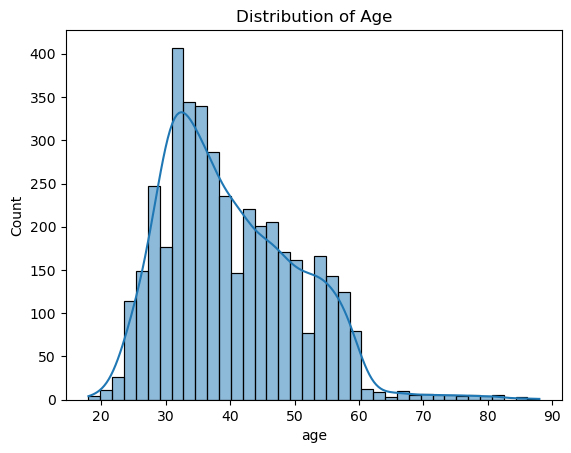

In [21]:
sns.histplot(df["age"], kde=True)
plt.title("Distribution of Age")
plt.show()

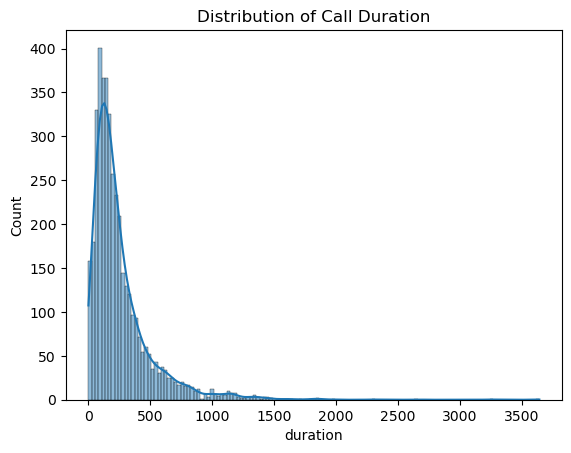

In [22]:
sns.histplot(df["duration"], kde=True)
plt.title("Distribution of Call Duration")
plt.show()

Age seem normally distributed while call durarion is heavily skewed to the right, so duration needs special consideration as thee might be leakage as duration is only known afer the call itself.


Visualise 2 categorical variables

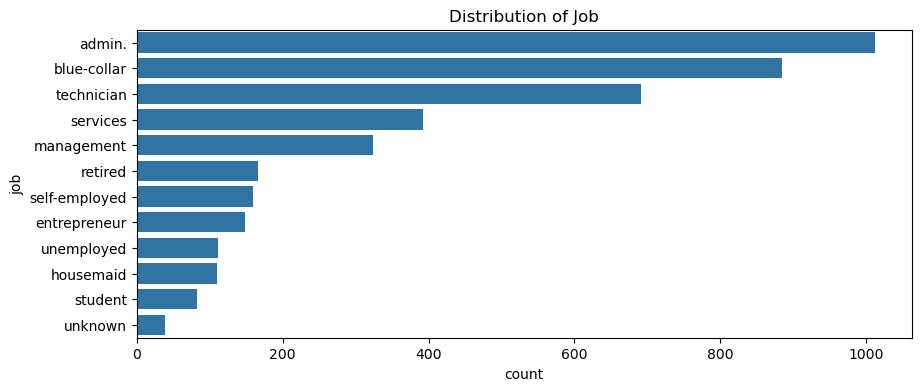

In [25]:
plt.figure(figsize=(10,4))
sns.countplot(y="job", data=df, order=df["job"].value_counts().index)
plt.title("Distribution of Job")
plt.show()

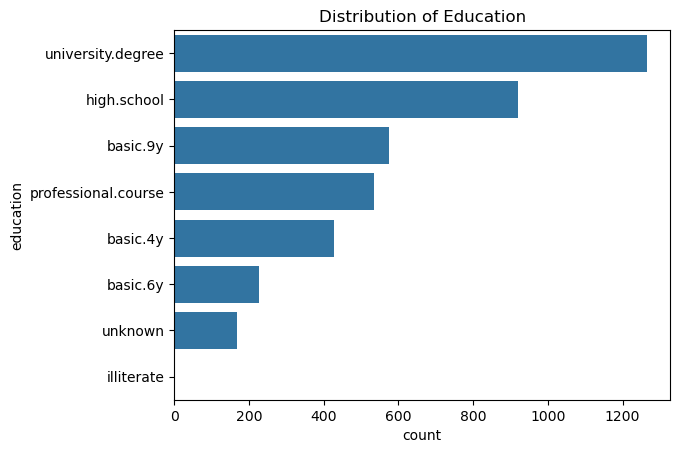

In [26]:
sns.countplot(y="education", data=df, order=df["education"].value_counts().index)
plt.title("Distribution of Education")
plt.show()

3) Task ordering

1.Identifying the Prediction Target
To determine which variables are features and which variables may cause leakage. 

2.Data Loading and Exploration (EDA)
Descrpitive and no learning required.

3.Data Splitting
Any transformations that learn from data must be fitted only on the training data.

4.Managing Missing Values
Done after data splitting to prevent preprocessing leakage.

5.Encoding Categorical Variables
Fit encoders on training data only and not full dataset to prevent learning unseen categories or frequency information from test data.

6.Feature Scaling
Scaling after splitting to prevent data leakage

7.Feature Selection
To prevent biasness, correlations are computed on training data

8.Addressing Class Imbalance
Occurs after preprocessing to prevent synthetic examples appearing in validation/test, contaminating evaluation.

9.Training Logistic Regression
Model is trained on training set before test set at the end.

Incorrect order:
-Scale entire dataset
-Then split

The scaler computes mean and variance using both training and test data. thus, training data indirectly contains information about test distribution and validation performance becomes overly optimistic, evaluation and performance will drop.




4) Data splitting

To seperate the feature and target:



In [31]:
X = df.drop(columns=["y"])
y = df["y"].map({"no": 0, "yes": 1})

Spltting of data into training and temporary (validation + test)
training: 70% 
validation:15%
test: 15%
Training set should be largest to estimate preprocessing parameters and train the model.
Validation set is used for model selection.
Test set is reserved for final unbiased evaluation.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y  # stratification with respect to target
)

Use stratified splitting to preserve the class distribution of the target variable across splits due to class imbalance.

In [35]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("Train class distribution:", y_train.mean())
print("Validation class distribution:", y_val.mean())
print("Test class distribution:", y_test.mean())

Train shape: (2883, 20)
Validation shape: (618, 20)
Test shape: (618, 20)
Train class distribution: 0.10960804717308359
Validation class distribution: 0.11003236245954692
Test class distribution: 0.10841423948220065


**Performing the split before any data-dependent transformation ensures that no form of preprocessing, target, proxy, temporal, or resampling leakage contaminates the validation and test sets, thereby preserving the integrity of model evaluation.

5) Managing missing values

Identify explicit values


In [39]:
df.isna().sum().sort_values(ascending=False)

age               0
campaign          0
nr.employed       0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
duration          0
job               0
day_of_week       0
month             0
contact           0
loan              0
housing           0
default           0
education         0
marital           0
y                 0
dtype: int64

The dataset contains few or no explicit NaN values. However, the absence of NaN does not imply the absence of missingness, as categorical variables may encode missing values as "unknown".

Identify implicit values

In [42]:
(df == "unknown").sum().sort_values(ascending=False)

default           803
education         167
housing           105
loan              105
job                39
marital            11
age                 0
poutcome            0
nr.employed         0
euribor3m           0
cons.conf.idx       0
cons.price.idx      0
emp.var.rate        0
duration            0
previous            0
pdays               0
campaign            0
day_of_week         0
month               0
contact             0
y                   0
dtype: int64

A few categorical variables contain the value "unknown" such as education and job which has missing values

Quantify level of missingness

In [45]:
df_temp = df.replace("unknown", np.nan)
missing_percentage = df_temp.isna().mean() * 100
missing_percentage.sort_values(ascending=False)

default           19.495023
education          4.054382
housing            2.549162
loan               2.549162
job                0.946832
marital            0.267055
age                0.000000
poutcome           0.000000
nr.employed        0.000000
euribor3m          0.000000
cons.conf.idx      0.000000
cons.price.idx     0.000000
emp.var.rate       0.000000
duration           0.000000
previous           0.000000
pdays              0.000000
campaign           0.000000
day_of_week        0.000000
month              0.000000
contact            0.000000
y                  0.000000
dtype: float64

Chosen Strategy:

For numerical variables, missing values are imputed using the median, as it is robust to skewness and appropriate for logistic regression. For categorical variables, missing values are imputed using the most frequent category, preserving dataset size and avoiding artificial ordering. Row deletion is avoided because missingness levels are not extreme and removing observations could distort the class distribution and make class imbalance worse.

Training-Only Fitting

All imputation operations are fitted exclusively on the training set, since they estimate parameters (e.g., medians, modes). Applying them before splitting would introduce preprocessing leakage, as statistics computed from validation or test data would contaminate the training process and inflate performance estimates.

Leakage Risk

If imputation were performed before splitting, the model would indirectly incorporate information from unseen data, resulting in optimistic and poor evaluation perfomance.

6) Encoding Categorical Variables

Identify categorical variables : 
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Nominal :'job', 'marital', 'default', 'housing', 'loan', 'contact', 'month as they have no numerical meaning

Ordinal: 'education ' Education levels follow an inherent progression (e.g., basic → high school → university) so it can have numerical meaning.

One hot encoding is used form nominal variables. Nominal variables have no intrinsic order. Assigning integer values (e.g., job = 1, 2, 3…) would introduce artificial ranking and distort distances between categories. Logistic Regression models a linear relationship between inputs and log-odds. Therefore, categories must be represented as independent binary indicators to avoid imposing unintended structure

Ordinal coding is used for ordinal variables. Education levels follow a meaningful order. Encoding them as increasing integers preserves monotonic structure and allows Logistic Regression to capture a linear trend in log-odds across education levels. This avoids unnecessary dimensional expansion compared to one-hot encoding.

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# Work on copies (good practice)
X_train_enc = X_train.copy()
X_val_enc   = X_val.copy()
X_test_enc  = X_test.copy()

# Treat "unknown" as missing (implicit missing)
def replace_unknown_with_nan(df_in):
    df_out = df_in.copy()
    for col in df_out.columns:
        if df_out[col].dtype == "object":
            df_out[col] = df_out[col].replace("unknown", np.nan)
    return df_out

X_train_enc = replace_unknown_with_nan(X_train_enc)
X_val_enc   = replace_unknown_with_nan(X_val_enc)
X_test_enc  = replace_unknown_with_nan(X_test_enc)

# Detect categorical columns
categorical_cols = X_train_enc.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = X_train_enc.select_dtypes(include=[np.number]).columns.tolist()

categorical_cols, numeric_cols

(['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'],
 ['age',
  'duration',
  'campaign',
  'pdays',
  'previous',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed'])

In [53]:
ordinal_cols = ["education"] if "education" in X_train_enc.columns else []
nominal_cols = [c for c in categorical_cols if c not in ordinal_cols]

ordinal_cols, nominal_cols

(['education'],
 ['job',
  'marital',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'])

In [54]:
education_order = [
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree"
]
education_categories = [education_order] 

In [55]:
# Ordinal pipeline: impute then ordinal encode
ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(categories=education_categories))
])

# Nominal pipeline: impute then one-hot encode
nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine into a ColumnTransformer
encoder = ColumnTransformer(
    transformers=[
        ("ord", ordinal_transformer, ordinal_cols),
        ("nom", nominal_transformer, nominal_cols),
        ("num", "passthrough", numeric_cols),
    ],
    remainder="drop"
)

In [56]:
# Fit ONLY on training
encoder.fit(X_train_enc)

# Transform all sets
X_train_encoded = encoder.transform(X_train_enc)
X_val_encoded   = encoder.transform(X_val_enc)
X_test_encoded  = encoder.transform(X_test_enc)

X_train_encoded.shape, X_val_encoded.shape, X_test_encoded.shape

((2883, 51), (618, 51), (618, 51))

In [57]:
print("Original number of features:", X_train_enc.shape[1])
print("Encoded number of features:", X_train_encoded.shape[1])
print("Added features:", X_train_encoded.shape[1] - X_train_enc.shape[1])

Original number of features: 20
Encoded number of features: 51
Added features: 31


A) Dimensionality:

One-Hot encoding increases dimensionality by creating one feature per category while ordinal encoding keeps dimensionality unchanged. Higher dimensionality increases model flexibility but may increase variance.

B) Interpretability of Coefficients

In Logistic Regression, coefficients represent changes in log-odds.
With One-Hot Encoding:
Each coefficient measures the log-odds change relative to a baseline category.
Interpretation is category-specific.

With Ordinal Encoding:
A single coefficient represents the change in log-odds per increase in category level.
Interpretation assumes monotonic effect.
Improper encoding (e.g., integer encoding for nominal data) would make coefficients uninterpretable.

C) Decision Boundaries of a Linear Model
Logistic Regression produces linear decision boundaries in feature space.
One-Hot Encoding allows the model to assign independent weights to categories.
Ordinal Encoding constrains the model to learn a monotonic relationship.
Arbitrary integer encoding of nominal variables would force a linear ordering constraint that does not reflect reality.
Thus, encoding directly affects model expressiveness and validity.

7) Feature Scaling

Identify numerical variable for scaling:
age
campaign
pdays
previous
emp.v
cons.price.idx
cons.conf.idx
euribor3m
nr.employed

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Identify numeric columns AFTER encoding step if needed
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()

# Fit only on training set
scaler.fit(X_train[numeric_cols])

# Transform all splits
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

We apply standardisation because Logistic Regression is optimized using gradient-based methods. Standardization ensures features are centered and have comparable variance. This improves convergence speed and numerical stability. Normalization (min-max scaling) is less appropriate because Logistic Regression does not use bounded inputs.

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Identify numeric columns AFTER encoding step if needed
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()

# Fit only on training set
scaler.fit(X_train[numeric_cols])

# Transform all splits
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

*Scaling is done on training set only because if these are computed on the full dataset before splitting:

The training data indirectly includes information about validation/test distributions.

This creates preprocessing leakage.

Model evaluation becomes optimistic and biased.

Effects of scaling on logistic regression:

A) Gradient-Based Optimization
Logistic Regression is trained using gradient descent (or variants).

Without scaling:
Features with larger magnitude produce larger gradients.
Optimization becomes unstable or slow.
Convergence may fail.

Scaling ensures:
Balanced gradient updates.
Faster convergence.

B) Magnitude and Comparability of Coefficients

Without scaling:
Coefficient size depends on unit scale.
Large coefficients may reflect large feature units, not importance.

With scaling:
Coefficients are comparable across features.
Magnitude better reflects predictive contribution.

C) Regularization Penalties

Logistic Regression often includes L2 regularization

If features are not scaled:
Features with larger scale are penalized differently.
Regularization becomes inconsistent

Scaling ensures:
Fair penalty across coefficients.
Proper regularization behavior.

8) Feature selection

We define “very low variance” as almost or equals zero (e.g., < 0.01 after scaling), or features that are nearly constant across observations.
This is because Logistic Regression estimates coefficients by identifying relationships between features and the log-odds of the target. A  feature with low or no variance cannot help with the model's predicting power and acccuracy.

In [68]:
import numpy as np

variances = np.var(X_train_encoded, axis=0)
low_var_threshold = 0.01
low_idx = np.where(variances < low_var_threshold)[0]

print(f"Low-variance threshold: {low_var_threshold}")
print("Number of low-variance columns:", len(low_idx))
low_idx[:20]

Low-variance threshold: 0.01
Number of low-variance columns: 3


array([15, 16, 25], dtype=int64)

Identify highly correlated features

In [70]:
import numpy as np
import pandas as pd

corr_threshold = 0.90 
num_cols = X_train.select_dtypes(include=[np.number]).columns
corr_matrix = X_train[num_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [
    (row, col, upper.loc[row, col])
    for row in upper.index for col in upper.columns
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > corr_threshold
]

print("Number of highly correlated pairs:", len(high_corr_pairs))
high_corr_pairs[:10]

Number of highly correlated pairs: 2


[('emp.var.rate', 'euribor3m', 0.9696484784019418),
 ('euribor3m', 'nr.employed', 0.9420867627325474)]

Value above 0.9 is considered high correlation.
Removing one variable preserves information while improving model stability.

* Duration is chosen to be removed because it is only known after the call ends and can make perfromance over optimistic --> target leakage.

* Feature selection must be done on the training set only because:

Variance estimates & correlation structure are data-dependent statistics.

Feature selection using validation/test data leaks information about those sets into the model.

This results in selection leakage, making performance overly optimistic and underestimating real-world error.

* If feature selection is performed on the full dataset before splitting:

a) the selected feature set may reflect patterns specific to the validation/test sets,

b) model evaluation becomes overly optimistic,

c) coefficients may appear more stable than they truly are,


9) Addressing class imbalance

Quantify class imbalance

In [77]:
y_train.value_counts()

y
0    2567
1     316
Name: count, dtype: int64

In [78]:
y_train.value_counts(normalize=True)


y
0    0.890392
1    0.109608
Name: proportion, dtype: float64

The training set is imbalanced: the majority class (“no” / "0") represents about 11%, and the minority class (“yes”/"1") about 89%.

For this prediction task, we particularly care about correctly identifying the minority class (customers who subscribe), so class imbalance is a concern.

A model that predicts only the majority class would already achieve high accuracy, so accuracy alone is misleading.

Proposed strategy: Random Oversampling
This method is simple and assumption-free.
For a linear model like Logistic Regression, oversampling mainly changes the relative weight of minority vs majority examples in the loss.
It does not invent synthetic patterns (unlike SMOTE/ADASYN), which keeps interpretation straightforward.

Stage in pipeline:
Resampling is part of training, so it must occur after preprocessing (encoding, scaling, etc.) and only on the training set.

In [81]:
from collections import Counter
from imblearn.over_sampling import RandomOverSampler

# Check original class balance
print("Before oversampling:", Counter(y_train))

# Use the processed training features here
X_train_for_resampling = X_train_scaled # <-- replace with your actual feature matrix

ros = RandomOverSampler(random_state=42)

X_train_res, y_train_res = ros.fit_resample(X_train_for_resampling, y_train)

print("After oversampling :", Counter(y_train_res))

Before oversampling: Counter({0: 2567, 1: 316})
After oversampling : Counter({0: 2567, 1: 2567})


* Resampling before splitting (on the full dataset) could result in:

The same duplicated (or synthetic) minority samples appearing in both the training and validation/test sets.

The class distribution of validation/test would be artificially balanced instead of reflecting the real problem.

Model performance estimates (accuracy, precision, recall, F1) would be over-optimistic, since the model would essentially be tested on examples it has already seen or on a distribution that does not match deployment.

* How class imbalance affect metrics:
 With a strong class imbalance, overall accuracy can be high even if the model completely fails to detect the minority class (predicting “no” for everyone).
 More informative metrics are precision and recall for the minority class: recall measures how many actual positive cases we catch, while precision measures how many predicted positives are correct.
Class imbalance typically pushes a default Logistic Regression model to favor the majority class, yielding high accuracy but low recall for the minority.
Oversampling rebalances the training data so the loss function penalizes errors on the minority class more strongly, which should improve recall (and often F1 score) at the cost of a small drop in overall accuracy.

10) Training a Logistic Regression Model

In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Identify columns
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Build preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Full model pipeline
model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

In [86]:
#BUILD AND TRAIN MODEL

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight=None))
])

logreg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object'))])),
                ('clf', LogisticRegression(max_iter=1000))])

In [87]:
#PREDICT ON VALIDATION AND METRICS
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# predictions on validation
y_val_pred = logreg_model.predict(X_val)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, zero_division=0)
rec = recall_score(y_val, y_val_pred, zero_division=0)

print(f"Validation Accuracy : {acc:.4f}")
print(f"Validation Precision: {prec:.4f}")
print(f"Validation Recall   : {rec:.4f}")

Validation Accuracy : 0.9191
Validation Precision: 0.7045
Validation Recall   : 0.4559


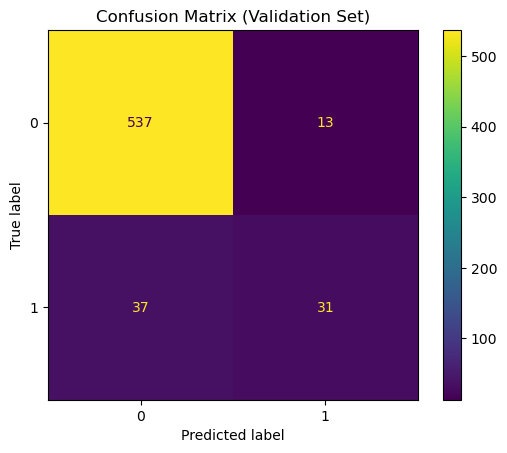

In [88]:
#confusion matrix display
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

Zero rule baseline and comparison

In [90]:
majority_class = y_train.value_counts().idxmax()
y_val_pred_zero = [majority_class] * len(y_val)

acc_zero = accuracy_score(y_val, y_val_pred_zero)

print(f"Zero Rule Accuracy (Validation): {acc_zero:.4f}")
print(f"LogReg Accuracy (Validation)   : {acc:.4f}")

if acc > acc_zero:
    print("Interpretation: Logistic Regression improves over the baseline, indicating meaningful predictive signal.")
else:
    print("Interpretation: Logistic Regression does not beat the baseline. This may suggest weak signal or issues in preprocessing.")

Zero Rule Accuracy (Validation): 0.8900
LogReg Accuracy (Validation)   : 0.9191
Interpretation: Logistic Regression improves over the baseline, indicating meaningful predictive signal.
